In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
df = pd.read_csv('/content/Single Layer Perceptron Dataset (1).csv')

In [4]:
print(df.shape)

(14, 5)


In [5]:
df.head()

,Pattern,Feature1,Feature2,Feature3,Class_Label
0,1.0,1.0,0.08,0.72,1.0
1,2.0,1.0,0.10,1.00,1.0
2,3.0,1.0,0.26,0.58,1.0
3,4.0,1.0,0.35,0.95,0.0
4,5.0,1.0,0.45,0.15,1.0


In [6]:
df.plot

In [7]:
plt.figure(figsize=(8,6))

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

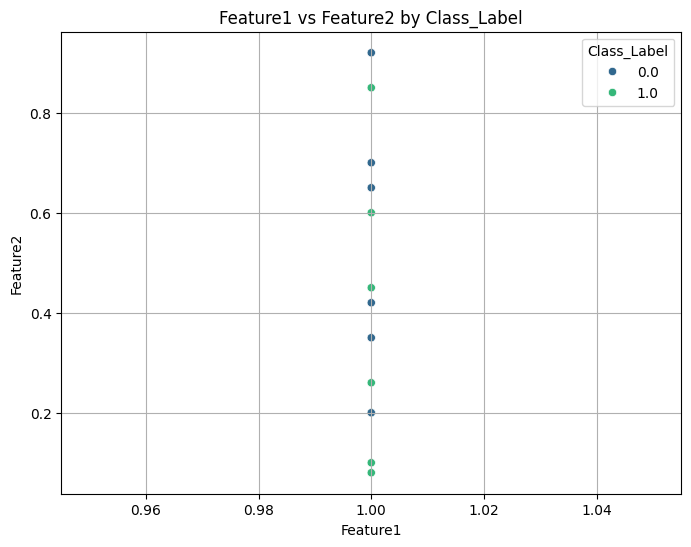

In [8]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Feature1', y='Feature2', hue='Class_Label', palette='viridis')
plt.title('Feature1 vs Feature2 by Class_Label')
plt.xlabel('Feature1')
plt.ylabel('Feature2')
plt.legend(title='Class_Label')
plt.grid(True)
plt.show()

<Axes: xlabel='Feature2', ylabel='Feature3'>

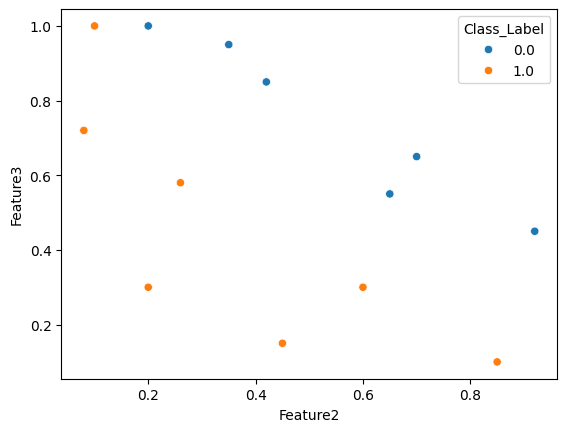

In [9]:
sns.scatterplot(data=df, x = 'Feature2', y = 'Feature3', hue ='Class_Label')

In [10]:
# Function to calculate the weights unitl the algorith the correctly classified all the data points
def calculate_weights(x_t,y_t,w):
    while True:
        m = 0
        for i in range(len(x_t)):
            X_i = np.insert(x_t[i],0, 1)
            if (y_t[i] * np.dot(w.T,X_i)) <=0:
                w = w + y_t[i]*X_i
                m = m + 1
        if m == 0:
            break

    return w

In [11]:
X = df[['Feature2','Feature3']].to_numpy()


In [12]:
# Changing class 0 to -1 for algorithm to work properly
y = df['Class_Label'].to_numpy()
y[y == 0] = -1
y

array([ 1.,  1.,  1., -1.,  1.,  1., -1., -1., -1., -1.,  1., -1.,  1.,
       nan])

In [13]:
# Initialize weights to zero, +1 for bias
weights = np.zeros(X.shape[1] + 1)

# calculate the weights
weights = calculate_weights(X,y, weights)
print(f' the new weights are: {weights}')

 the new weights are: [ 5.   -3.96 -4.45]


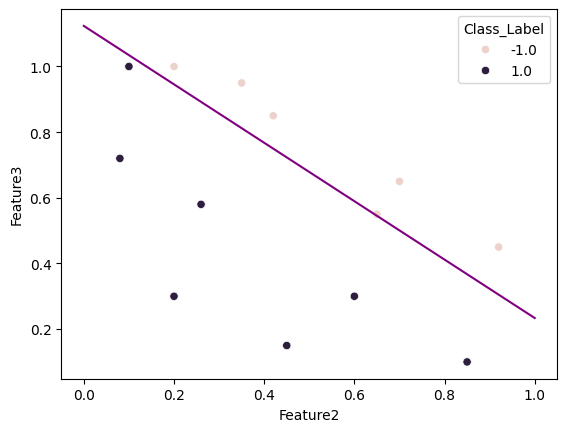

In [14]:
# plot the data and linear boundary using weights/bias calculated above
x1 = np.linspace(0, 1, 10)
x2 = (-weights[1]/weights[2]) * x1 - weights[0]/weights[2]

sns.scatterplot(data=df, x = 'Feature2', y = 'Feature3', hue ='Class_Label')
plt.plot(x1, x2, color='purple', label='Boundary')